# PREDICTING DIAMOND PRICES USING REGRESSION MODEL

### **Background**

Diamonds are well sought after due to their inherent characteristics being one of the strongest susbtances in the world. Because they are extremely valueable, they are often traded across the world. To that effect there are standards or metrics used to ascertain the quality and therefore price of diamonds. They are known as the four C's.

**A. Cut**

Refers to the quality of the diamond's cut, not the shape or size. It is the most important of the C's. It also determines how the diamond interacts with light. Per the GIA system, diamond cuts are graded as excellent, very good, good, fair, poor.


**B. Clarity**

This speaks to the number of natural imperfections (known as inclusions) present in a stone and whether you can see them with the unaided eye. The systeme rates diamonds from Flawless (FL) to Included (I).

- FL, IF = Internally Flawless
- VVS1, VVS2 = Very Very Slightly Included
- VS1, VS2 = Very Slightly Included
- SI1, SI2, SI3 = Slightly Included
- I1,I2, I3 = Included

**C. Color**

Diamond colors are rated within a D to Z scale, where D = completely colorless (and the most expensive) and Z = light yellow hue. Typical standard diamond quality falls within the D to J color grade.

- DEF = Colorless
- GHIJ = Near colorless
- KLM = Faint yellow
- NOPQR = Very light yellow
- STUBVWXYZ = Light yellow

**D. Carat**

This is a measurement of the actual weight of the diamond. According to the GIA, 1 carat = 0.2 grams. Specifically, diamond carat is divided into 100 points meaning a 50-point diamond weighs 0.50 carats.

## Problem statement

Build an interactive real-time system which can take features of a diamond and predict its price.

| Feature | Description|
|:---|:---|
|Price |price in US dollars|
|Carat|weight of diamond|
|Cut|Quality of the cut (Fair, good, very good, premium, ideal)|
|Clarity|how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))|
|x |length in mm|
|y |width in mm|
|z |depth in mm|
|depth |total depth percentage = $\frac{2*z}{(x+y)}$|
|table |width of top of diamond relative to widest point|

<hr>

### Import Libraries

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# load dataset
df = pd.read_csv('diamonds.csv')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [6]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

In [7]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [10]:
df.head(10)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


In [13]:
# value counts of categorical columns

cat_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in cat_cols:
    print("*"*5, col, "*"*5)
    count = df[col].value_counts()
    print(count)
    print()

***** cut *****
cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

***** color *****
color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

***** clarity *****
clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64



In [15]:
df.describe(exclude=[np.number])

,cut,color,clarity
count,53940,53940,53940
unique,5,7,8
top,Ideal,G,SI1
freq,21551,11292,13065


## Step 2. EDA

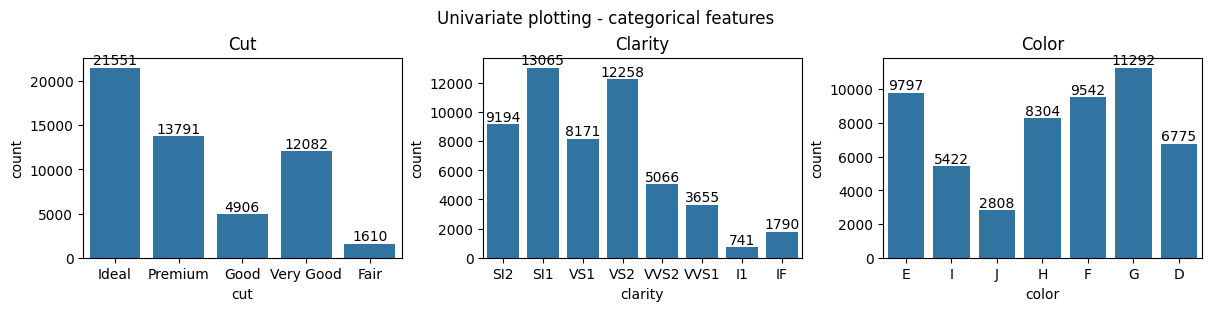

In [20]:
# Univariate Analysis of the Categorical Variables

def add_bar_labels(ax):
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2, p.get_height()), 
                    ha='center', va='bottom')

fig, axs = plt.subplots(1, 3, figsize=(12,3), constrained_layout=True)
fig.suptitle('Univariate plotting - categorical features')

axs[0].set_title('Cut')
sns.countplot(data=df, x='cut', ax=axs[0])
add_bar_labels(axs[0])

axs[1].set_title('Clarity')
sns.countplot(data=df, x='clarity', ax=axs[1])
add_bar_labels(axs[1])

axs[2].set_title('Color')
sns.countplot(data=df, x='color', ax=axs[2])
add_bar_labels(axs[2])

plt.show()

<Axes: title={'center': 'Color vs Price'}, xlabel='price', ylabel='color'>

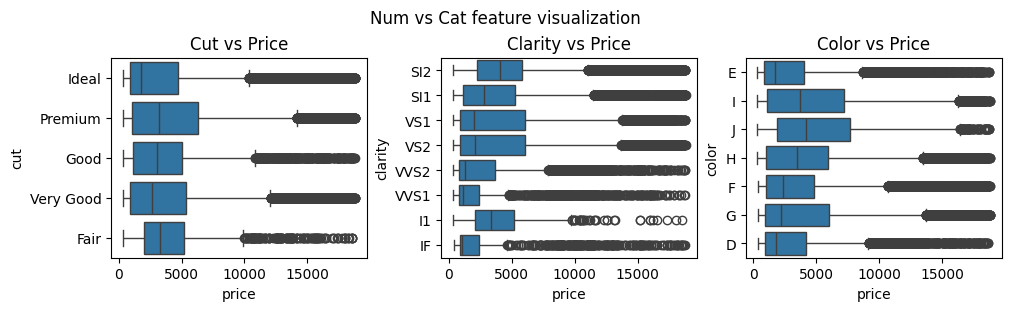

In [23]:
#Cat vs Num analysis - Bivariate Analysis

fig, axs = plt.subplots(1,3, figsize=(10,3), constrained_layout=True)
fig.suptitle('Num vs Cat feature visualization')

axs[0].set_title('Cut vs Price')
sns.boxplot(data=df, x='price', y='cut', ax=axs[0])

axs[1].set_title('Clarity vs Price')
sns.boxplot(data=df, x='price', y='clarity', ax=axs[1])


axs[2].set_title('Color vs Price')
sns.boxplot(data=df, x='price', y='color', ax=axs[2])

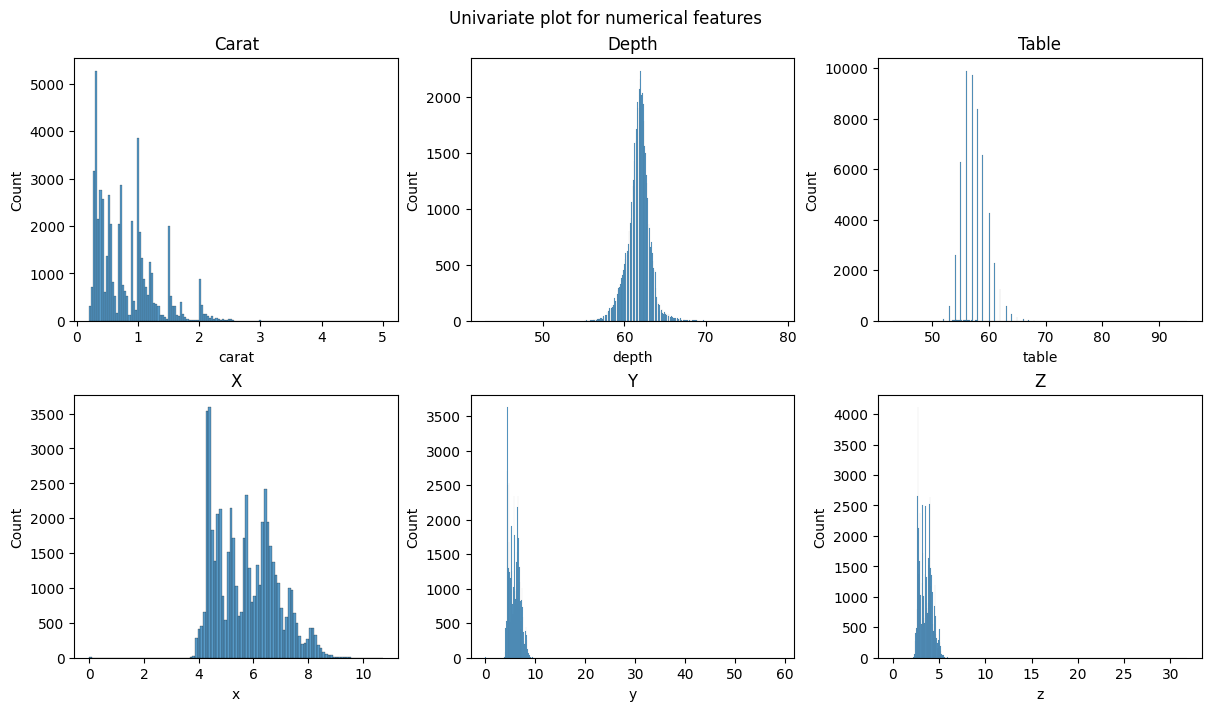

In [25]:
# Univariate histplot

fig, axs =plt.subplots(2,3, figsize=(12,7), constrained_layout=True)
fig.suptitle('Univariate plot for numerical features')

axs[0,0].set_title('Carat')
sns.histplot(data=df, x='carat', ax=axs[0,0])

axs[0,1].set_title('Depth')
sns.histplot(data=df, x='depth', ax=axs[0,1])

axs[0,2].set_title('Table')
sns.histplot(data=df, x='table', ax=axs[0,2])


axs[1,0].set_title('X')
sns.histplot(data=df, x='x', ax=axs[1,0])

axs[1,1].set_title('Y')
sns.histplot(data=df, x='y', ax=axs[1,1])

axs[1,2].set_title('Z')
sns.histplot(data=df, x='z', ax=axs[1,2])

plt.show()

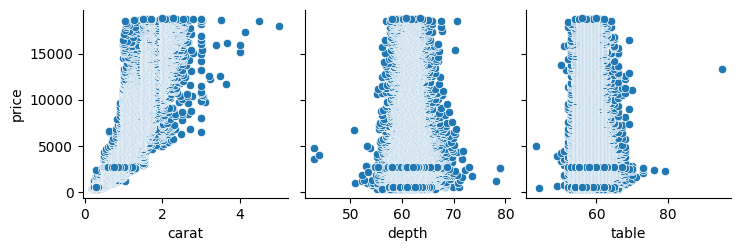

In [28]:
#Num vs Num 1

sns.pairplot(data=df, 
            x_vars=['carat', 'depth', 'table'],
            y_vars='price')

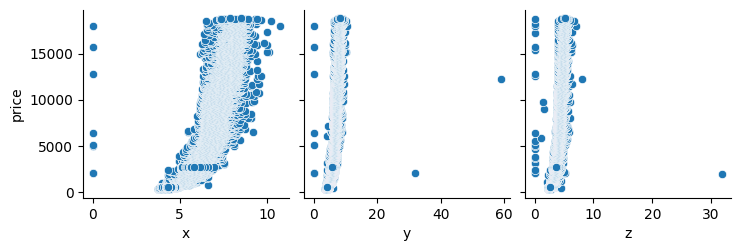

In [29]:
#Num vs Num 2

sns.pairplot(data=df, 
            x_vars=['x', 'y', 'z'],
            y_vars='price')

### Step 3 - Segregate Input and Output

In [31]:
# segregate inputs and output

X = df.drop(columns=['price'])
y = df['price']

### Step 4 - Split data into train and test sets

In [32]:
# split data into train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(40455, 9) (13485, 9)
(40455,) (13485,)


## Step 5 - Apply Data Preparation on Training Data

In [33]:
# 1. separate numerical and categorical features on the input training set

X_train_cat = X_train.select_dtypes(include=['object'])
X_train_num = X_train.select_dtypes(include=['number'])

In [35]:
# 2. using standardization for rescaling
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

# after rescaling, column names are lost since the dataframe is converted to a numpy ndarray
X_train_num_transformed = pd.DataFrame(std_scaler.fit_tranform(X_train_num),
                                       columns=std_scaler.get_feature_names_out(),
                                       index=X_train_num.index)
X_train_num_transformed.describe().round(3)

,carat,depth,table,x,y,z
count,40455.000,40455.000,40455.000,40455.000,40455.000,40455.000
mean,-0.000,0.000,-0.000,0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.260,-13.095,-6.484,-5.104,-4.978,-4.985
25%,-0.838,-0.457,-0.652,-0.909,-0.880,-0.885
50%,-0.206,0.101,-0.203,-0.036,-0.020,-0.026
75%,0.511,0.520,0.694,0.722,0.700,0.707
max,8.882,12.041,9.667,4.463,46.156,39.819


In [37]:
# defining the ordering for categorical columns - Lowest to Highest

cut_cat = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_cat = ['J', 'I', 'G', 'F', 'E', 'D']
clarity_cat = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

# creating the ordinal encoder
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder(categories = [cut_cat, color_cat, clarity_cat],
                                 handle_unknown='use_encoded_value',
                                 unknown_value=-1,
                                 encoded_missing_value=-5)

# applying the encoder
X_train_cat_transformed = pd.DataFrame(ordinal_encoder.fit_transform(X_train_cat),
                                       columns=ordinal_encoder.get_feature_names_out(),
                                       index=X_train_cat.index)

X_train_cat_transformed.head()

,cut,color,clarity
441,3.0,-1.0,1.0
50332,2.0,5.0,2.0
35652,4.0,2.0,5.0
9439,2.0,-1.0,4.0
15824,1.0,3.0,3.0


In [38]:
# concatenate X_train_num_transformed and X_train_cat_transformed

X_train_transformed = pd.concat([X_train_num_transformed, X_train_cat_transformed], axis=1)

X_train_transformed.head()

,carat,depth,table,x,y,z,cut,color,clarity
441,0.194920,-1.085697,0.694368,0.472201,0.430971,0.312528,3.0,-1.0,1.0
50332,-0.205679,1.567623,-1.997562,-0.142482,-0.107276,0.058918,2.0,5.0,2.0
35652,-1.027961,0.659908,-0.202942,-1.247129,-1.235860,-1.166861,4.0,2.0,5.0
9439,0.216004,0.380611,0.694368,0.347483,0.378883,0.411154,2.0,-1.0,4.0
15824,0.447930,-0.806400,2.040332,0.703821,0.656688,0.566137,1.0,3.0,3.0


In [87]:
X_train_transformed.columns

Index(['carat', 'depth', 'table', 'x', 'y', 'z', 'cut', 'color', 'clarity'], dtype='object')

In [40]:
X_train_transformed.dtypes

carat      float64
depth      float64
table      float64
x          float64
y          float64
z          float64
cut        float64
color      float64
clarity    float64
dtype: object

### Step 6 - Apply Data Preparation on Test Data

In [51]:
# separate cat and num features

X_test_cat = X_test.select_dtypes(include=['object'])
X_test_num = X_test.select_dtypes(include=['int64', 'float64'])

# applying transformation on numerical columns
X_test_num_transformed = pd.DataFrame(std_scaler.transform(X_test_num),
                                      columns=std_scaler.get_feature_names_out(),
                                      index=X_test_num.index)

# applying transformation on categorical columns
X_test_cat_transformed = pd.DataFrame(ordinal_encoder.transform(X_test_cat),
                                      columns=ordinal_encoder.get_feature_names_out(),
                                      index=X_test_num.index)

# concatenating
X_test_transformed = pd.concat([X_test_num_transformed, X_test_cat_transformed], axis=1)

X_test_transformed.head()

,carat,depth,table,x,y,z,cut,color,clarity
10176,0.637687,0.171139,-1.100252,0.783997,0.795591,0.805657,4.0,-1.0,1.0
16083,1.038286,0.590084,-0.651597,1.095792,1.038670,1.143803,4.0,-1.0,2.0
13420,0.848529,-0.457279,0.245713,1.024525,0.925812,0.904283,3.0,1.0,2.0
20407,1.481053,-0.596928,-0.651597,1.514489,1.411971,1.355144,4.0,3.0,2.0
8909,0.216004,-0.038334,-0.202942,0.392025,0.413609,0.397064,2.0,3.0,3.0


### Step 7,8,9 - Training and Testing Phase | Linear Regression

In [53]:
%%time

from sklearn.linear_model import LinearRegression
from sklearn import metrics

LR_regressor = LinearRegression()
LR_regressor.fit(X_train_transformed, y_train)

y_test_pred = LR_regressor.predict(X_test_transformed)

LR_MAE = metrics.mean_absolute_error(y_test, y_test_pred)

print("Model's error: ", LR_MAE)

Model's error:  828.3725514326804
CPU times: total: 46.9 ms
Wall time: 56.7 ms


In [55]:
output_df = pd.DataFrame({'Actual': y_test})

output_df['LR predictions'] = y_test_pred
# output_df.head()

In [56]:
output_df

,Actual,LR predictions
10176,4733,4834.760460
16083,6424,6956.116354
13420,5510,6484.393756
20407,8770,9847.956335
8909,4493,4711.351694
...,...,...
52283,2494,3241.771747
10789,4861,4148.986149
1190,2932,3837.933545
3583,3422,4082.842770


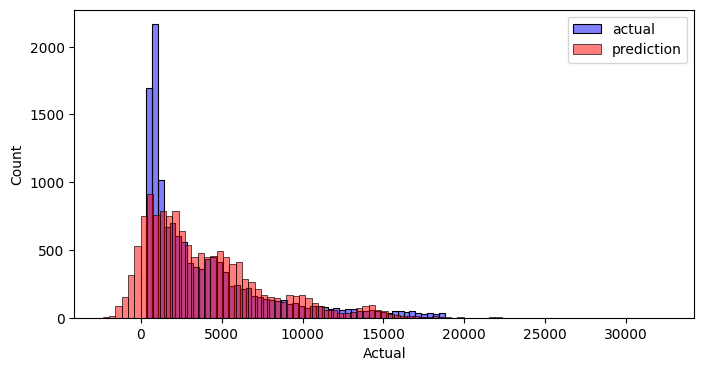

In [57]:
fig, ax = plt.subplots(figsize=(8,4))
sns.histplot(output_df['Actual'], color='blue', alpha=0.5, label='actual')
sns.histplot(output_df['LR predictions'], color='red', alpha=0.5, label='prediction')

plt.legend()

### Using KNN Regression

In [63]:
%%time

from sklearn.neighbors import KNeighborsRegressor
from sklearn import metrics

KNN_regressor = KNeighborsRegressor()
KNN_regressor.fit(X_train_transformed, y_train)

y_test_pred = KNN_regressor.predict(X_test_transformed)

KNN_MAE = metrics.mean_absolute_error(y_test, y_test_pred)

print("Model's Error: ", KNN_MAE)

Model's Error:  385.0157063403782
CPU times: total: 1.67 s
Wall time: 1.98 s


In [66]:
output_df['KNN predictions'] = y_test_pred
output_df.head()

,Actual,LR predictions,KNN predictions
10176,4733,4834.760460,4620.0
16083,6424,6956.116354,7109.0
13420,5510,6484.393756,5098.0
20407,8770,9847.956335,12477.0
8909,4493,4711.351694,4678.0


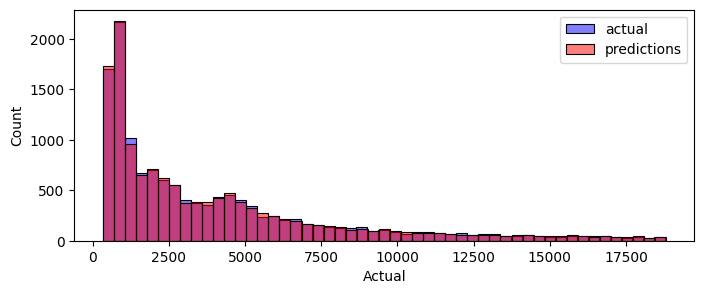

In [67]:
fig, ax = plt.subplots(figsize=(8,3))

sns.histplot(output_df['Actual'], color='blue', alpha=0.5, label='actual')
sns.histplot(output_df['KNN predictions'], color='red', alpha=0.5, label='predictions')

plt.legend()

### Using Decision Tree Regression

In [65]:
%%time

from sklearn.tree import DecisionTreeRegressor
from sklearn import metrics

DT_regressor = DecisionTreeRegressor()
DT_regressor.fit(X_train_transformed, y_train)

y_test_pred = DT_regressor.predict(X_test_transformed)

DT_MAE = metrics.mean_absolute_error(y_test, y_test_pred)

print("Model's Error: ", DT_MAE)

Model's Error:  357.51405265109383
CPU times: total: 500 ms
Wall time: 934 ms


In [74]:
output_df['DT predictions'] = y_test_pred
output_df

,Actual,LR predictions,KNN predictions,DT predictions
10176,4733,4834.760460,4620.0,4620.0
16083,6424,6956.116354,7109.0,7109.0
13420,5510,6484.393756,5098.0,5098.0
20407,8770,9847.956335,12477.0,12477.0
8909,4493,4711.351694,4678.0,4678.0
...,...,...,...,...
52283,2494,3241.771747,2442.0,2442.0
10789,4861,4148.986149,4166.0,4166.0
1190,2932,3837.933545,3267.0,3267.0
3583,3422,4082.842770,2856.0,2856.0


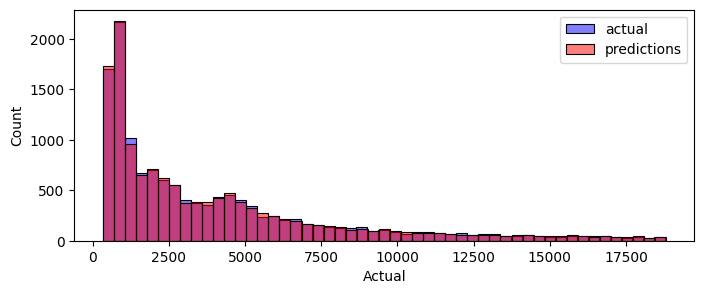

In [75]:
fig, ax = plt.subplots(figsize=(8,3))

sns.histplot(output_df['Actual'], color='blue', alpha=0.5, label='actual')
sns.histplot(output_df['DT predictions'], color='red', alpha=0.5, label='predictions')
plt.legend()

In [76]:
%%time

from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

RF_regressor = RandomForestRegressor()
RF_regressor.fit(X_train_transformed, y_train)

y_test_pred = RF_regressor.predict(X_test_transformed)

RF_MAE = metrics.mean_absolute_error(y_test, y_test_pred)
print("Model's error: ", RF_MAE)

Model's error:  269.70525954676276
CPU times: total: 30 s
Wall time: 39.6 s


In [78]:
output_df['RF predictions'] = y_test_pred
output_df

,Actual,LR predictions,KNN predictions,DT predictions,RF predictions
10176,4733,4834.760460,4620.0,4620.0,4638.410000
16083,6424,6956.116354,7109.0,7109.0,7030.240000
13420,5510,6484.393756,5098.0,5098.0,5252.960000
20407,8770,9847.956335,12477.0,12477.0,11505.010000
8909,4493,4711.351694,4678.0,4678.0,4718.740000
...,...,...,...,...,...
52283,2494,3241.771747,2442.0,2442.0,2433.440000
10789,4861,4148.986149,4166.0,4166.0,4365.950000
1190,2932,3837.933545,3267.0,3267.0,3043.629167
3583,3422,4082.842770,2856.0,2856.0,2911.260000


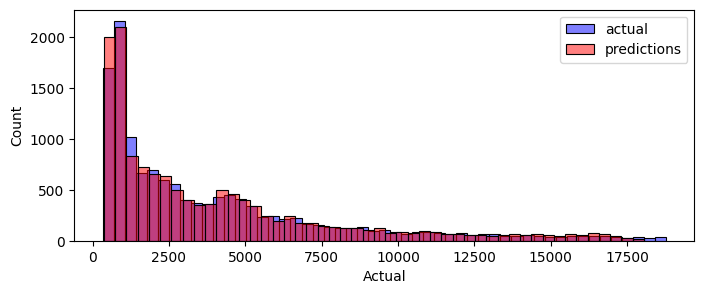

In [79]:
fig, ax = plt.subplots(figsize=(8,3))

sns.histplot(output_df['Actual'], color='blue', alpha=0.5, label='actual')
sns.histplot(output_df['RF predictions'], color='red', alpha=0.5, label='predictions')

plt.legend()

### Comparing all Methods

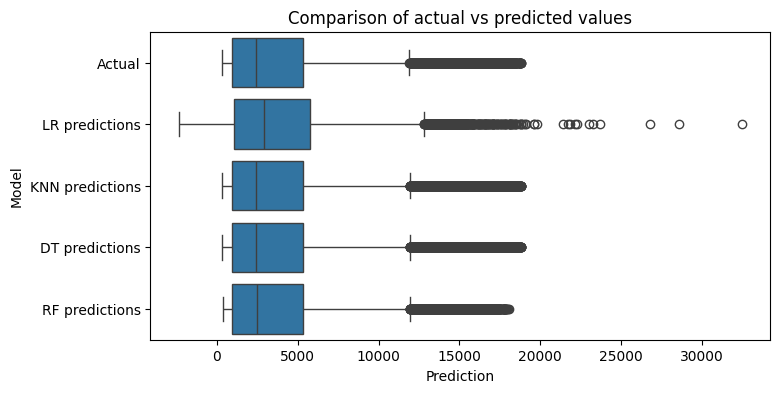

In [80]:
df_melted = pd.melt(output_df, var_name='Model', value_name='Prediction')

fig, ax = plt.subplots(figsize=(8,4))
sns.boxplot(x='Prediction', y='Model', data=df_melted)

plt.title('Comparison of actual vs predicted values')

plt.show()

In [81]:
df_melted

,Model,Prediction
0,Actual,4733.000000
1,Actual,6424.000000
2,Actual,5510.000000
3,Actual,8770.000000
4,Actual,4493.000000
...,...,...
67420,RF predictions,2433.440000
67421,RF predictions,4365.950000
67422,RF predictions,3043.629167
67423,RF predictions,2911.260000


In [84]:
#comparing the MAE values
# Comparing the MAE values
mae_data = {
    'Algorithm/Model': ['Linear regression', 'KNN', 'Decision Tree', 'Random Forest'],
    'Mean Absolute Value': [LR_MAE, KNN_MAE, DT_MAE, RF_MAE]
}

# Create the DataFrame
models = pd.DataFrame(data=mae_data)

# Display the DataFrame
models

,Algorithm/Model,Mean Absolute Value
0,Linear regression,828.372551
1,KNN,385.015706
2,Decision Tree,357.514053
3,Random Forest,269.705260


### Dump our Model into a Pickle file (.pkl)

In [86]:
#importing required library
import joblib

# Save the trained model
joblib.dump(RF_regressor, 'Streamlit_files/random_forest_model.pkl')

# Save the scaler
joblib.dump(std_scaler, 'Streamlit_files/scaler.pkl')

# Save the encoder (if applicable, for categorical features)
joblib.dump(ordinal_encoder, 'Streamlit_files/encoder.pkl')

print("Model, scaler, and encoder saved successfully!")

Model, scaler, and encoder saved successfully!


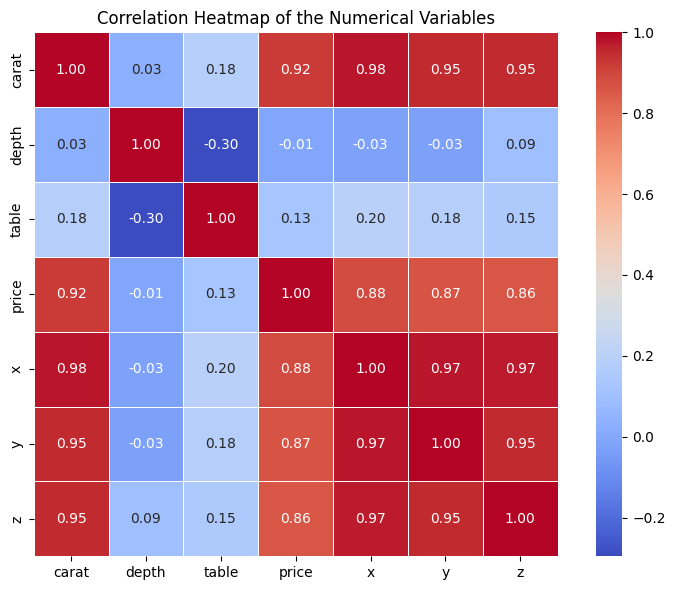

In [88]:
# Using heatmap to show correlation matrix
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, square=True)
plt.title("Correlation Heatmap of the Numerical Variables")

plt.tight_layout()
plt.show()